In [1]:
import os
from pathlib import Path
print(os.getcwd())
print(list(Path.cwd().iterdir())[:20])

c:\Users\milkl\OneDrive\문서\웰니스 공모전\wellness analyze\Anti-Churn-Committee\notebooks\hyerim
[WindowsPath('c:/Users/milkl/OneDrive/문서/웰니스 공모전/wellness analyze/Anti-Churn-Committee/notebooks/hyerim/README.md'), WindowsPath('c:/Users/milkl/OneDrive/문서/웰니스 공모전/wellness analyze/Anti-Churn-Committee/notebooks/hyerim/test.ipynb')]


In [2]:
# 데이터 처리 및 분석
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 시드 설정
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [3]:
# 현재 최대 행/열 출력 제한 확인
print(f"현재 최대 행 수: {pd.get_option('display.max_rows')}")
print(f"현재 최대 열 수: {pd.get_option('display.max_columns')}")

# 제한 없이 출력하도록 설정 변경 (None은 제한 없음을 의미)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None) # 컬럼 너비 제한 해제

현재 최대 행 수: 100
현재 최대 열 수: None


In [4]:
# 데이터 로드
user_df = pd.read_csv('../../../../01_User_Profile.csv')
event_df = pd.read_csv('../../../../02_Event_Log.csv')

print("="*60)
print("데이터 로드 완료!")
print("="*60)
print(f"\nuser_df: {user_df.shape}")
print(f"event_df: {event_df.shape}")


데이터 로드 완료!

user_df: (12500, 6)
event_df: (1757262, 5)


In [5]:
print(user_df.info())
print()
print(event_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 12500 entries, 0 to 12499
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   User_ID      12500 non-null  str   
 1   가입일자         12500 non-null  str   
 2   가입경로         12363 non-null  str   
 3   기기           12379 non-null  str   
 4   알림수신동의여부     12384 non-null  object
 5   알림수신동의_변경일자  1976 non-null   str   
dtypes: object(1), str(5)
memory usage: 586.1+ KB
None

<class 'pandas.DataFrame'>
RangeIndex: 1757262 entries, 0 to 1757261
Data columns (total 5 columns):
 #   Column      Dtype
---  ------      -----
 0   User_ID     str  
 1   Event_Time  str  
 2   Event_Type  str  
 3   Session_ID  str  
 4   알림_유형       str  
dtypes: str(5)
memory usage: 67.0 MB
None


In [6]:
display(user_df.describe().T)
display(event_df.describe().T)

,count,unique,top,freq
User_ID,12500,12500,U0000001,1
가입일자,12500,146,2025-02-15,173
가입경로,12363,2,퍼포먼스광고,6852
기기,12379,2,iOS,7175
알림수신동의여부,12384,2,True,7984
알림수신동의_변경일자,1976,148,2025-05-29,32


,count,unique,top,freq
User_ID,1757262,12453,U0006192,697
Event_Time,1757262,1495136,2025-03-15 14:05:00,12
Event_Type,1730806,10,앱실행,728657
Session_ID,1515760,736281,e783135554,8
알림_유형,218882,3,리마인드,85830


In [7]:
missing_summary1 = pd.DataFrame({
    'missing_count': user_df.isna().sum(),
    'missing_ratio_percent': user_df.isna().mean() * 100
})

missing_summary1

,missing_count,missing_ratio_percent
User_ID,0,0.000
가입일자,0,0.000
가입경로,137,1.096
기기,121,0.968
알림수신동의여부,116,0.928
알림수신동의_변경일자,10524,84.192


In [8]:
missing_summary2 = pd.DataFrame({
    'missing_count': event_df.isna().sum(),
    'missing_ratio_percent': event_df.isna().mean() * 100
})

missing_summary2

,missing_count,missing_ratio_percent
User_ID,0,0.000000
Event_Time,0,0.000000
Event_Type,26456,1.505524
Session_ID,241502,13.743084
알림_유형,1538380,87.544145


In [9]:
display(user_df.head())
display(event_df.head())

,User_ID,가입일자,가입경로,기기,알림수신동의여부,알림수신동의_변경일자
0,U0000001,2025-01-25,오가닉,iOS,True,NaN
1,U0000002,2025-05-06,오가닉,iOS,False,2025-05-24
2,U0000003,2025-05-14,오가닉,iOS,False,NaN
3,U0000004,2025-02-23,퍼포먼스광고,Android,True,NaN
4,U0000005,2025-02-18,퍼포먼스광고,Android,True,NaN


,User_ID,Event_Time,Event_Type,Session_ID,알림_유형
0,U0000001,2025-01-25 07:25:45,앱실행,2858201769,NaN
1,U0000001,2025-01-25 07:26:15,온보딩_완료,2858201769,NaN
2,U0000001,2025-01-25 07:26:55,챌린지_탐색,2858201769,NaN
3,U0000001,2025-01-25 07:27:55,챌린지참여,2858201769,NaN
4,U0000001,2025-01-25 20:30:00,알림수신,NaN,광고성


In [10]:
# user_df 형변환

user_df['User_ID'] = user_df['User_ID'].astype('string')
user_df['가입일자'] = pd.to_datetime(user_df['가입일자'], errors='coerce')
user_df['알림수신동의_변경일자'] = pd.to_datetime(user_df['알림수신동의_변경일자'], errors='coerce')
user_df['가입경로'] = user_df['가입경로'].astype('category')
user_df['기기'] = user_df['기기'].astype('category')
user_df['알림수신동의여부'] = user_df['알림수신동의여부'].astype('boolean')


# event_df 형변환

event_df['User_ID'] = event_df['User_ID'].astype('string')
event_df['Session_ID'] = event_df['Session_ID'].astype('string')
event_df['Event_Time'] = pd.to_datetime(event_df['Event_Time'], errors='coerce')
event_df['Event_Type'] = event_df['Event_Type'].astype('category')
event_df['알림_유형'] = event_df['알림_유형'].astype('category')

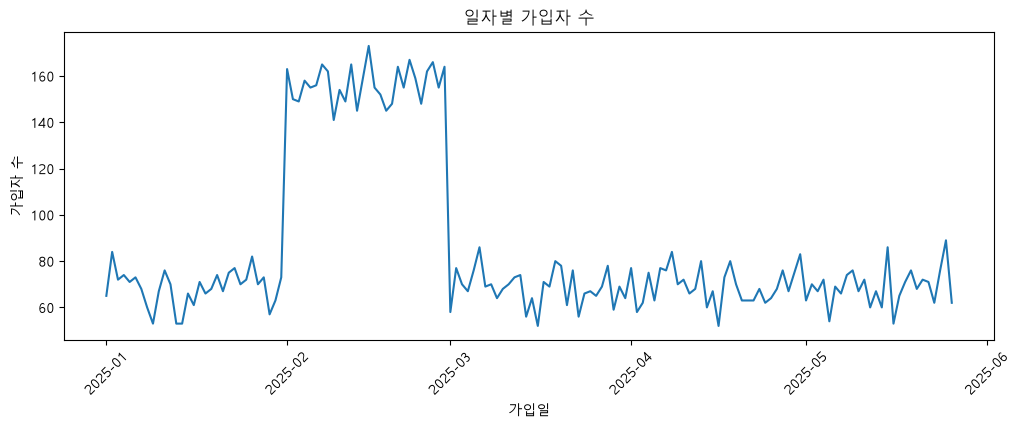

In [11]:
# 일자별 가입자 수
signup_daily = user_df.groupby(user_df['가입일자'].dt.date).size().reset_index(name='user_count')

signup_daily.columns = ['가입일','user_count']

plt.figure(figsize=(12,4))
plt.plot(signup_daily['가입일'], signup_daily['user_count'])
plt.title('일자별 가입자 수')
plt.xlabel('가입일')
plt.ylabel('가입자 수')
plt.xticks(rotation=45)
plt.show()

- 2월에 신규 유저가 평소보다 약 2배 이상 일시적으로 증가함
- -> 2월에 유입된 신규 유저의 질 또는 유입 경로가 기존 유저와 달라서 30일 리텐션 하락에 영향을 줬을 수 있음
- -> 가입 코호트별 리텐션 분석 필요

In [12]:
# 범주형 컬럼 분포 확인 함수
def categorical_summary(df, col):
    summary = pd.DataFrame({
        'count': df[col].value_counts(dropna=False),
        'ratio': df[col].value_counts(dropna=False, normalize=True) * 100
    })
    
    return summary

In [13]:
display(categorical_summary(user_df, '가입경로'))
display(categorical_summary(user_df, '기기'))
display(categorical_summary(user_df, '알림수신동의여부'))


,count,ratio
가입경로,,
퍼포먼스광고,6852,54.816
오가닉,5511,44.088
NaN,137,1.096


,count,ratio
기기,,
iOS,7175,57.400
Android,5204,41.632
NaN,121,0.968


,count,ratio
알림수신동의여부,,
True,7984,63.872
False,4400,35.2
<NA>,116,0.928


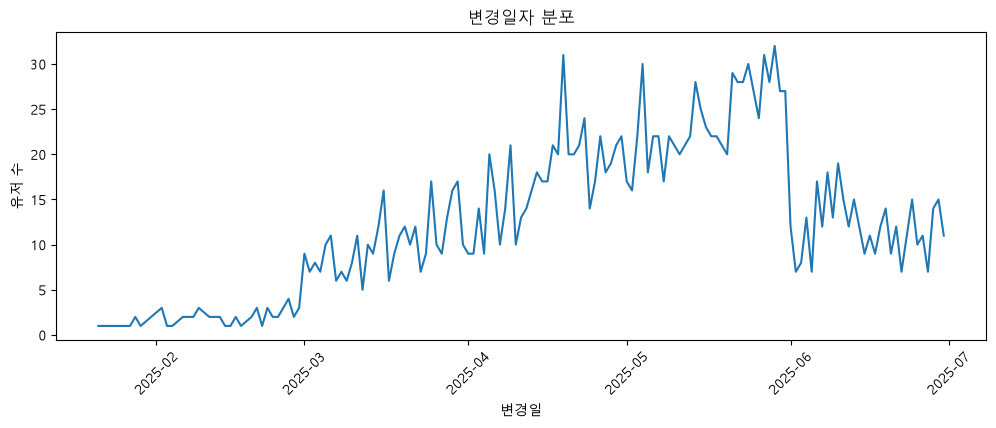

In [14]:
# 변경일자 분포 확인
change_daily = user_df.groupby(user_df['알림수신동의_변경일자'].dt.date).size()

plt.figure(figsize=(12, 4))
change_daily.plot()
plt.title('변경일자 분포')
plt.xlabel('변경일')
plt.ylabel('유저 수')
plt.xticks(rotation=45)
plt.show()

In [15]:
# 이벤트 발생 유저 수
print(event_df['User_ID'].nunique())
len(user_df['User_ID'])

12453


12500

결측된 47명이 로그 수집 오류 기간에 신규로 들어온 사람들


User_ID
U0006192    697
U0011974    694
U0003827    687
U0009639    685
U0009477    675
U0008419    669
U0002307    667
U0008943    667
U0009724    667
U0006116    664
Name: count, dtype: Int64

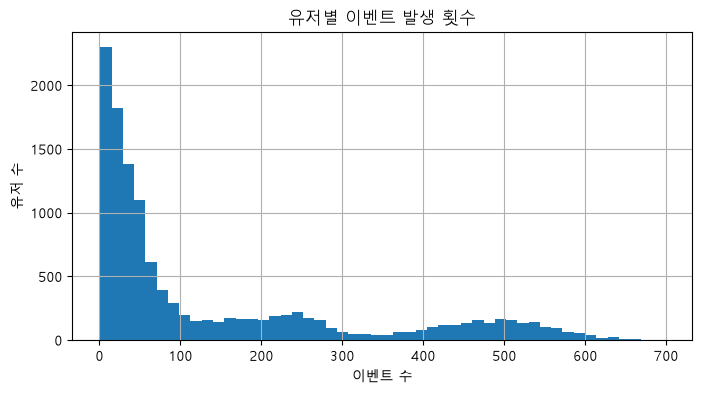

In [22]:
display(event_df['User_ID'].value_counts().head(10))

plt.figure(figsize=(8,4))
event_df['User_ID'].value_counts().hist(bins=50)

plt.title('유저별 이벤트 발생 횟수')
plt.xlabel('이벤트 수')
plt.ylabel('유저 수')
plt.show()

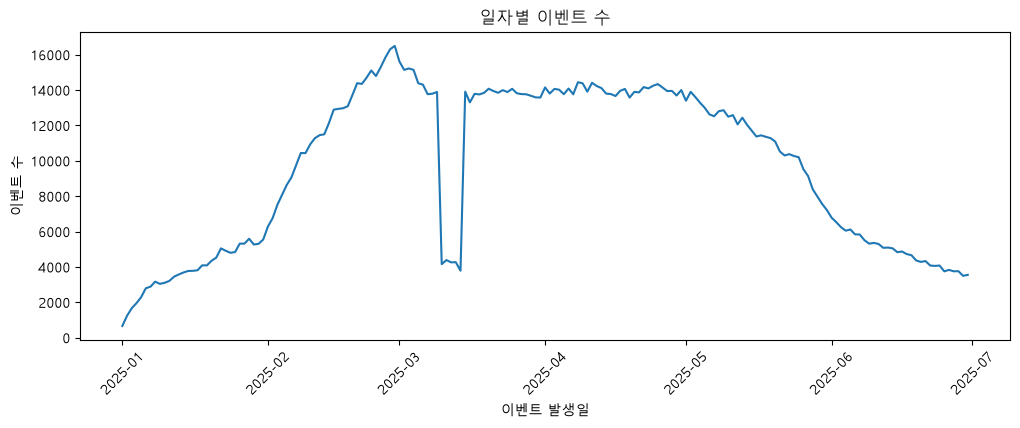

In [17]:
# 일자별 이벤트 수
event_daily = event_df.groupby(event_df['Event_Time'].dt.date).size()

plt.figure(figsize=(12, 4))
event_daily.plot()

plt.title('일자별 이벤트 수')
plt.xlabel('이벤트 발생일')
plt.ylabel('이벤트 수')
plt.xticks(rotation=45)
plt.show()

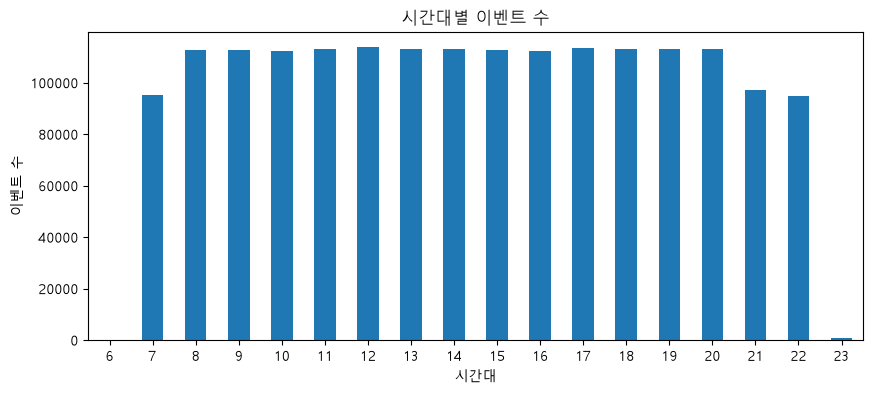

In [18]:
# 시간대별 이벤트 수
event_hourly = event_df['Event_Time'].dt.hour.value_counts().sort_index()

plt.figure(figsize=(10, 4))
event_hourly.plot(kind='bar')
plt.title('시간대별 이벤트 수')
plt.xlabel('시간대')
plt.ylabel('이벤트 수')
plt.xticks(rotation=0)
plt.show()

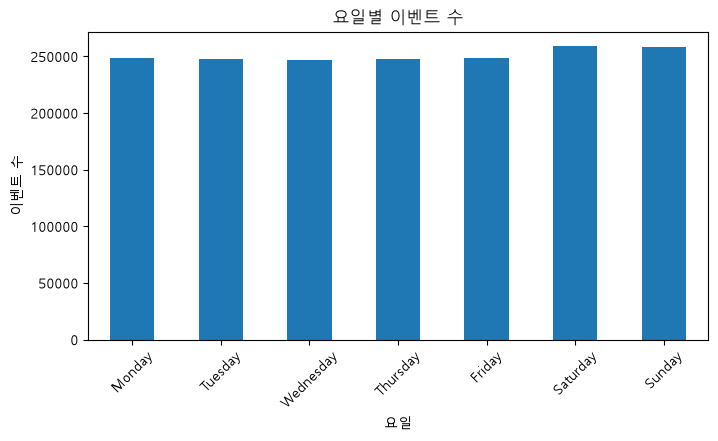

In [19]:
# 요일별 이벤트 수

weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

event_weekday = event_df['Event_Time'].dt.day_name().value_counts().reindex(weekday_order)

event_weekday.plot(kind='bar', figsize=(8, 4))

plt.title('요일별 이벤트 수')
plt.xlabel('요일')
plt.ylabel('이벤트 수')
plt.xticks(rotation=45)
plt.show()

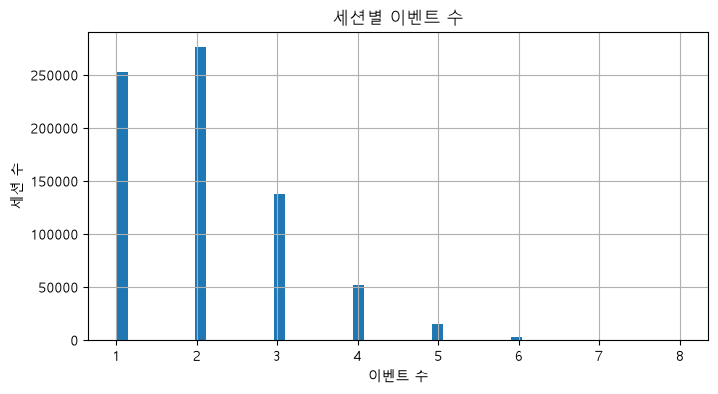

In [20]:
# 세션별 이벤트 수

plt.figure(figsize=(8, 4))
event_df['Session_ID'].value_counts().hist(bins=50)

plt.title('세션별 이벤트 수')
plt.xlabel('이벤트 수')
plt.ylabel('세션 수')
plt.show()

In [21]:
display(categorical_summary(event_df, 'Event_Type'))
display(categorical_summary(event_df, '알림_유형'))

,count,ratio
Event_Type,,
앱실행,728657,41.465473
수면기록,242978,13.827079
알림수신,194324,11.058340
운동기록,131269,7.470087
마음챙김,130344,7.417448
식단기록,101366,5.768406
챌린지참여,96829,5.510220
챌린지_탐색,78101,4.444471
NaN,26456,1.505524


,count,ratio
알림_유형,,
NaN,1538380,87.544145
리마인드,85830,4.884303
광고성,78262,4.453633
챌린지_알림,54790,3.117919
